<a href="https://colab.research.google.com/github/AleynaCifcibasi/Python-ile-Machine-Learning-al-malar-ve-projeleri/blob/main/Python_Oturum_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#lojistik Regresyon

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
X , y = make_classification(
    n_samples=1000,
    n_informative=2,
    n_features=5,
    n_classes=2,
    random_state=42
)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)


In [4]:
lr_model = LogisticRegression()
lr_model.fit(X_train,y_train)

LogisticRegression()

In [5]:
y_pred = lr_model.predict(X_test)
basari = accuracy_score(y_test, y_pred)
print("Başarı skoru : ",basari)

Başarı skoru :  0.89


#KNN

In [6]:
from sklearn.neighbors import KNeighborsClassifier


In [7]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [8]:
y_pred = knn_model.predict(X_test)
basari = accuracy_score(y_test, y_pred)
print("Başarı skoru : ",basari)

Başarı skoru :  0.9033333333333333


In [9]:
from sklearn.svm import SVC

#SVM-SVR

In [10]:
from sklearn.svm import SVC

In [11]:
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [12]:
y_pred = svm_model.predict(X_test)
basari = accuracy_score(y_test, y_pred)
print("Başarı skoru : ",basari)

Başarı skoru :  0.8866666666666667


#YSA

In [13]:
from google.colab import drive
import pandas as pd

In [14]:
drive.mount('/content/drive')


Mounted at /content/drive


In [15]:
veri_yolu = '/content/drive/MyDrive/Tech İstanbul/memekanseri.data'

In [16]:
veri = pd.read_csv(veri_yolu, header=None)

In [17]:
kolon_isimleri = veri.iloc[0]

In [18]:
print(kolon_isimleri)
print(veri.head(10))

0    30
1    64
2     1
3     1
Name: 0, dtype: int64
    0   1   2  3
0  30  64   1  1
1  30  62   3  1
2  30  65   0  1
3  31  59   2  1
4  31  65   4  1
5  33  58  10  1
6  33  60   0  1
7  34  59   0  2
8  34  66   9  2
9  34  58  30  1


In [19]:
veri.columns = ["Yas","Ameliyat_Yili","Bulgular","Canli"]
print(veri.head(10))

   Yas  Ameliyat_Yili  Bulgular  Canli
0   30             64         1      1
1   30             62         3      1
2   30             65         0      1
3   31             59         2      1
4   31             65         4      1
5   33             58        10      1
6   33             60         0      1
7   34             59         0      2
8   34             66         9      2
9   34             58        30      1


In [20]:
veri.loc[veri['Canli']==2,'Canli']=0
print(veri.head(10))

   Yas  Ameliyat_Yili  Bulgular  Canli
0   30             64         1      1
1   30             62         3      1
2   30             65         0      1
3   31             59         2      1
4   31             65         4      1
5   33             58        10      1
6   33             60         0      1
7   34             59         0      0
8   34             66         9      0
9   34             58        30      1


In [21]:
veri['Canli'] = veri['Canli'].astype('int64')
print(veri.dtypes)

Yas              int64
Ameliyat_Yili    int64
Bulgular         int64
Canli            int64
dtype: object


In [22]:
from sklearn.preprocessing import MinMaxScaler

X = veri.drop('Canli',axis=1)
y = veri['Canli']

In [23]:
ölceklendirme = MinMaxScaler()
X = ölceklendirme.fit_transform(X)
X = pd.DataFrame(X, columns=['Yas','Ameliyat_Yili','Bulgular'])
print(X.head(10))

        Yas  Ameliyat_Yili  Bulgular
0  0.000000       0.545455  0.019231
1  0.000000       0.363636  0.057692
2  0.000000       0.636364  0.000000
3  0.018868       0.090909  0.038462
4  0.018868       0.636364  0.076923
5  0.056604       0.000000  0.192308
6  0.056604       0.181818  0.000000
7  0.075472       0.090909  0.000000
8  0.075472       0.727273  0.173077
9  0.075472       0.000000  0.576923


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [25]:
from keras.models import Sequential
from keras.layers import Dense

In [26]:
print(X_train.shape)

(244, 3)


In [27]:
ysa_model = Sequential()

In [28]:
ysa_model.add(Dense(128,input_shape=(X_train.shape[1],),activation='relu'))
ysa_model.add(Dense(64,activation='relu'))
ysa_model.add(Dense(32,activation='relu'))
ysa_model.add(Dense(16,activation='relu'))
ysa_model.add(Dense(1,activation='sigmoid'))
ysa_model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
ysa_model.fit(X_train, y_train, epochs=10000,verbose=0)

In [30]:
kayıp, basari = ysa_model.evaluate(X_test, y_test)
print("Kayıp : ",kayıp)
print("Başarı : ",basari)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 446ms/step - accuracy: 0.6129 - loss: 15.3230
Kayıp :  15.322986602783203
Başarı :  0.6129032373428345


#K-Means Clustering

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [32]:
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

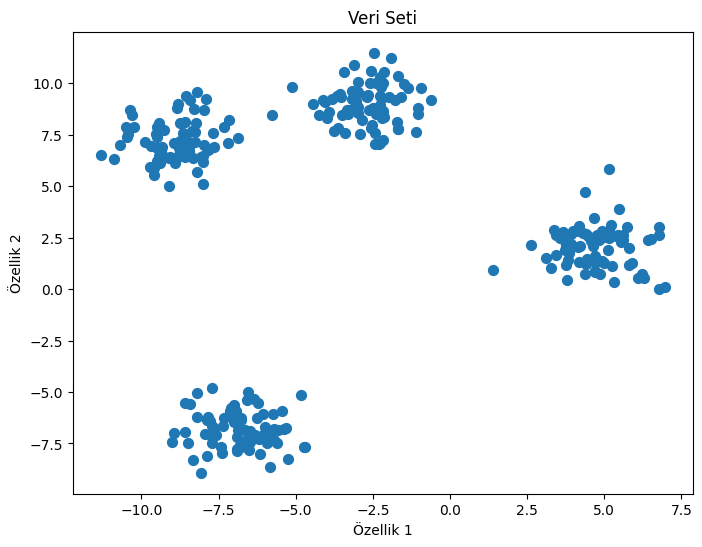

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1],s=50)

plt.title('Veri Seti')
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.show()

In [34]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)

KMeans(n_clusters=5)

In [35]:
centers = kmeans.cluster_centers_
labels = kmeans.labels_

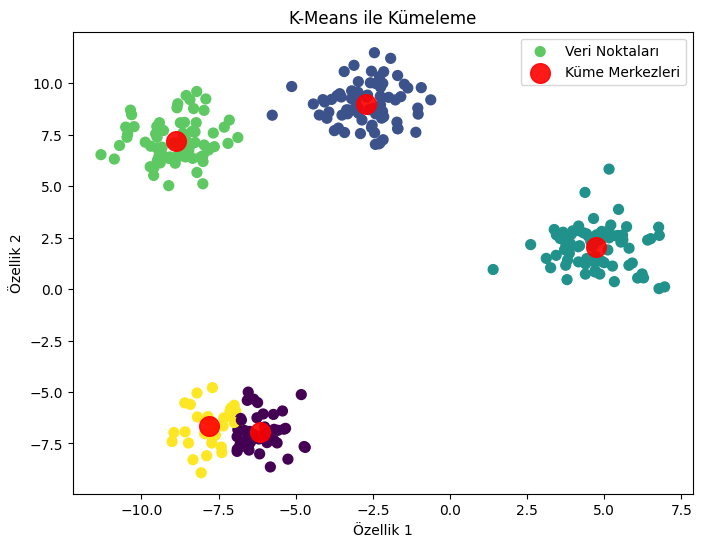

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1],c=labels, s=50, label='Veri Noktaları')
plt.scatter(centers[:,0], centers[:,1],c='red',s=200, alpha=0.9,label='Küme Merkezleri')

plt.title('K-Means ile Kümeleme')
plt.xlabel('Özellik 1')
plt.ylabel('Özellik 2')
plt.legend()
plt.show()

#Hiyerarşik Kümeleme

In [37]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, _ = make_blobs(
    n_samples=300,
    centers=4,
    random_state=42
)

In [39]:
hiyerarsik = linkage(X, 'single')


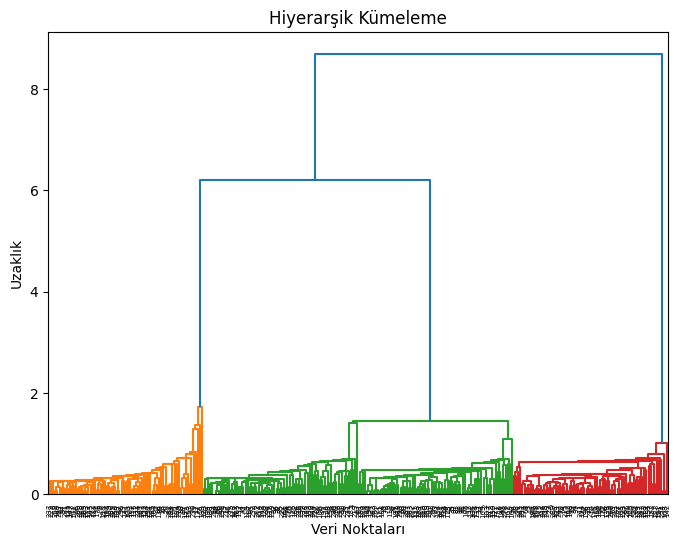

In [40]:
plt.figure(figsize=(8,6))

dendrogram(
    hiyerarsik,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)

plt.title('Hiyerarşik Kümeleme')
plt.xlabel('Veri Noktaları')
plt.ylabel('Uzaklık')
plt.show()

In [41]:
hiyerarsik2 = linkage(X,'complete')

kümeleme = fcluster(
    hiyerarsik2,
    20,
    criterion='distance'
)

In [42]:
print('Oluşan küme sayısı : ',len(np.unique(kümeleme)))

Oluşan küme sayısı :  2


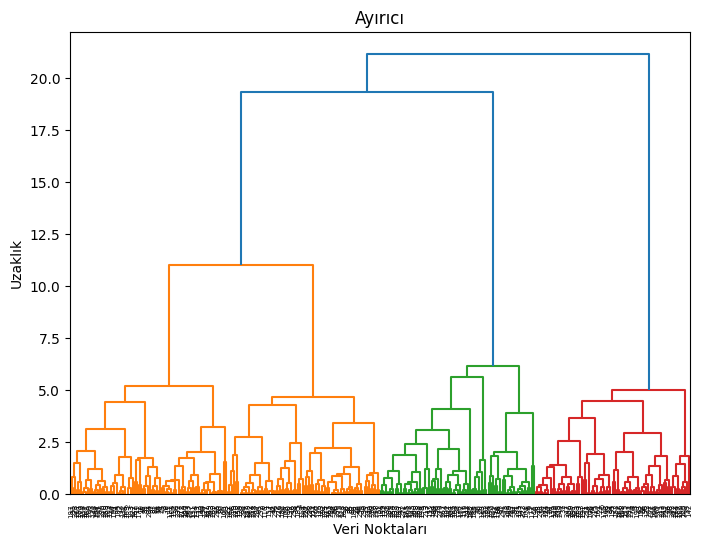

In [43]:
plt.figure(figsize=(8,6))

dendrogram(
    hiyerarsik2,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)

plt.title('Ayırıcı')
plt.xlabel('Veri Noktaları')
plt.ylabel('Uzaklık')
plt.show()